# process fits, save results (PCN)

project = ```iP-VAE```, host = ```mach```, device = ```cuda:1```

**Motivation**: <br>

From ```/mnt/sata/Dekel/pc_mnist``` to ```../tmp/results_mar2025```

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, 'PoissonVAE'))
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from sklearn import linear_model
from sklearn.metrics import classification_report


device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Results dir

In [3]:
results_dir = pjoin(tmp_dir, 'results_2025-03')
os.makedirs(results_dir, exist_ok=True)

len(os.listdir(results_dir))

614

## MNIST data

In [4]:
trn, vld, _ = make_dataset('MNIST', device)
x_vld, g_vld = vld.tensors
g_trn = trn.tensors[1]

g_trn = tonp(g_trn)
g_vld = tonp(g_vld)

x_vld = x_vld.flatten(start_dim=1)
x_vld.shape

torch.Size([10000, 784])

## Fits: pc & ipc

In [5]:
root = '/mnt/sata/Dekel/pc_mnist'
fits = sorted(os.listdir(root), key=alphanum_sort_key)
len(fits)

10

### Process: pc & ipc

In [7]:
for f in fits:
    run = dict(np.load(pjoin(root, f)))
    recon_vld = torch.tensor(run['x_val'], device=device)

    # (1) info
    str_model, seed = f.rstrip('.npz').split('_')
    info = {
        'dataset': 'MNIST',
        'str_model': str(str_model),
        'seed': int_from_str(seed),
        'n_latents': 64,
        'n_params': 125_968,
    }

    # (2) results
    results = {}
    # clf accuracy
    lr = linear_model.LogisticRegression().fit(
    			X=run['z_trn'], y=g_trn)
    results['clf_accuracy'] = {
        'trn': classification_report(
            y_true=g_trn,
            y_pred=lr.predict(run['z_trn']),
            output_dict=True)['accuracy'],
        'vld': classification_report(
            y_true=g_vld,
            y_pred=lr.predict(run['z_val']),
            output_dict=True)['accuracy'],
    }
    # r2, mse, %-zeros    
    results['r2'] = compute_r2(
        true=x_vld,
        pred=recon_vld,
    ).mean().item()
    results['mse'] = torch.sum(
        (x_vld - recon_vld) ** 2,
        dim=1,
    ).mean(0).item()
    results['%-zeros'] = (run['z_val'] == 0).mean()

    # (3) info and results put together
    obj_to_save = {'info': info, 'results': results}
    
    # (4) display the fit
    print(f"\n\nrun name:\t{f}")
    print(obj_to_save)

    # (5) save
    file_name = f.replace('.npz', '.npy')
    file_name = f"pcn_{file_name}"
    save_obj(
        obj=obj_to_save,
        file_name=file_name,
        save_dir=results_dir,
        verbose=True,
    )
    print('-' * 90)

run name:       ipc_seed0.npz

{
    'info': {'dataset': 'MNIST', 'str_model': 'ipc', 'seed': 0, 'n_latents': 64, 'n_params': 125968},
    'results': {
        'clf_accuracy': {'trn': 0.9137333333333333, 'vld': 0.9163},
        'r2': 0.8978682160377502,
        'mse': 7.121669292449951,
        '%-zeros': 0.0
    }
}

[PROGRESS] 'pcn_ipc_seed0.npy' saved at
/home/hadi/Dropbox/git/jb-progress-2025/tmp/results_2025-03


------------------------------------------------------------------------------------------

run name:       ipc_seed1.npz

...

------------------------------------------------------------------------------------------

run name:       pc_seed4.npz

{
    'info': {'dataset': 'MNIST', 'str_model': 'pc', 'seed': 4, 'n_latents': 64, 'n_params': 125968},
    'results': {
        'clf_accuracy': {'trn': 0.8972666666666667, 'vld': 0.9053},
        'r2': 0.8965579867362976,
        'mse': 7.222329616546631,
        '%-zeros': 0.0
    }
}

[PROGRESS] 'pcn_pc_seed4.npy' saved at
/home/hadi/Dropbox/git/jb-progress-2025/tmp/results_2025-03


------------------------------------------------------------------------------------------

## Fits: dcpc

In [8]:
root = '/mnt/sata/Dekel/dcpc_mnist'
fits = sorted(os.listdir(root), key=alphanum_sort_key)
len(fits)

5

In [19]:
print(fits)

['seed0.npz', 'seed1.npz', 'seed2.npz', 'seed3.npz', 'seed4.npz']

In [20]:
run = dict(np.load(pjoin(root, fits[0])))
print({k: v.shape for k, v in run.items()})

{
    'x_trn_hat': (54000, 1, 28, 28),
    'z_trn_hat': (54000, 20),
    'x_val_hat': (6000, 1, 28, 28),
    'z_val_hat': (6000, 20),
    'x_tst_hat': (10000, 1, 28, 28),
    'z_tst_hat': (10000, 20)
}

### Process: dcpc

In [28]:
for f in fits:
    run = dict(np.load(pjoin(root, f)))
    run = {k: v.reshape(len(v), -1) for k, v in run.items()}
    recon_vld = torch.tensor(run['x_tst_hat'], device=device)

    # (1) info
    info = {
        'dataset': 'MNIST',
        'str_model': 'dcpc',
        'seed': int_from_str(f.rstrip('.npz')),
        'n_latents': 20,
        'n_params': 319_000,
    }

    # (2) results
    results = {}
    # clf accuracy
    z_trn = np.concatenate([
        run['z_trn_hat'],
        run['z_val_hat'],
    ])
    lr = linear_model.LogisticRegression().fit(
    			X=z_trn, y=g_trn)
    results['clf_accuracy'] = {
        'trn': classification_report(
            y_true=g_trn,
            y_pred=lr.predict(z_trn),
            output_dict=True)['accuracy'],
        'vld': classification_report(
            y_true=g_vld,
            y_pred=lr.predict(run['z_tst_hat']),
            output_dict=True)['accuracy'],
    }
    # r2, mse, %-zeros    
    results['r2'] = compute_r2(
        true=x_vld,
        pred=recon_vld,
    ).mean().item()
    results['mse'] = torch.sum(
        (x_vld - recon_vld) ** 2,
        dim=1,
    ).mean(0).item()
    results['%-zeros'] = (run['z_tst_hat'] == 0).mean()

    # (3) info and results put together
    obj_to_save = {'info': info, 'results': results}
    
    # (4) display the fit
    print(f"\n\nrun name:\t{f}")
    print(obj_to_save)

    # (5) save
    file_name = f.replace('.npz', '.npy')
    file_name = f"pcn_dcpc_{file_name}"
    # save_obj(
    #     obj=obj_to_save,
    #     file_name=file_name,
    #     save_dir=results_dir,
    #     verbose=True,
    # )
    print('-' * 90)

run name:       seed0.npz

{
    'info': {'dataset': 'MNIST', 'str_model': 'dcpc', 'seed': 0, 'n_latents': 20, 'n_params': 319000},
    'results': {
        'clf_accuracy': {'trn': 0.11433333333333333, 'vld': 0.1157},
        'r2': 0.09263421595096588,
        'mse': 64.8829574584961,
        '%-zeros': 0.0
    }
}

------------------------------------------------------------------------------------------

run name:       seed1.npz

{
    'info': {'dataset': 'MNIST', 'str_model': 'dcpc', 'seed': 1, 'n_latents': 20, 'n_params': 319000},
    'results': {
        'clf_accuracy': {'trn': 0.11431666666666666, 'vld': 0.1157},
        'r2': 0.08894339203834534,
        'mse': 65.07510375976562,
        '%-zeros': 0.0
    }
}

...

{
    'info': {'dataset': 'MNIST', 'str_model': 'dcpc', 'seed': 3, 'n_latents': 20, 'n_params': 319000},
    'results': {
        'clf_accuracy': {'trn': 0.11453333333333333, 'vld': 0.116},
        'r2': 0.09057500958442688,
        'mse': 65.00411224365234,
        '%-zeros': 0.0
    }
}

------------------------------------------------------------------------------------------

run name:       seed4.npz

{
    'info': {'dataset': 'MNIST', 'str_model': 'dcpc', 'seed': 4, 'n_latents': 20, 'n_params': 319000},
    'results': {
        'clf_accuracy': {'trn': 0.11413333333333334, 'vld': 0.1157},
        'r2': 0.09319479018449783,
        'mse': 64.82550048828125,
        '%-zeros': 0.0
    }
}

------------------------------------------------------------------------------------------

In [30]:

recon_vld.shape

torch.Size([10000, 784])

In [ ]:
compute_r2(
    true=x_vld,
    pred=recon_vld,
).mean().item()

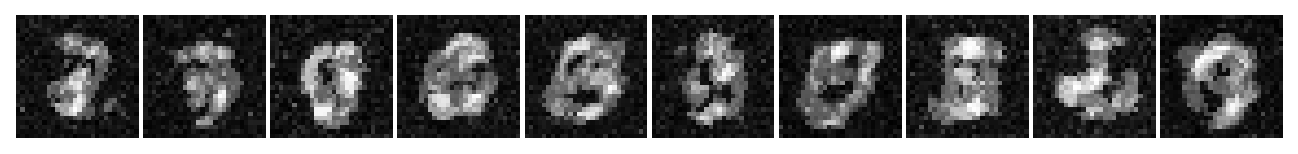

In [34]:
recon_vld = torch.tensor(run['x_tst_hat'], device=device)
plot_weights(recon_vld[:10].reshape(-1, 28, 28), nrows=1);

## Accu dependence on C

In [19]:
accu = collections.defaultdict(list)

for f in tqdm(fits):
    run = dict(np.load(pjoin(root, f)))

    for C in [1e-4, 1e-3, 1e-2, 1e-1, 1, 5, 10, 100, 1e3, 1e4, 1e5]:
        lr = linear_model.LogisticRegression(C=C, max_iter=5000).fit(
                    X=run['z_trn'], y=g_trn)
        clf_accuracy = {
            'trn': classification_report(
                y_true=g_trn,
                y_pred=lr.predict(run['z_trn']),
                output_dict=True)['accuracy'],
            'vld': classification_report(
                y_true=g_vld,
                y_pred=lr.predict(run['z_val']),
                output_dict=True)['accuracy'],
        }
        accu['fit'].append(f)
        accu['C'].append(C)
        accu['trn'].append(clf_accuracy['trn'])
        accu['vld'].append(clf_accuracy['trn'])

accu = pd.DataFrame(accu)

100%|███████████████████████████████████████████| 10/10 [08:56<00:00, 53.70s/it]


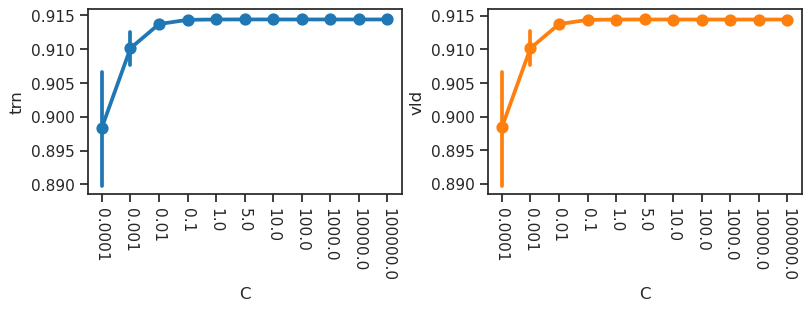

In [29]:
fig, axes = create_figure(1, 2, (8, 3))
sns.pointplot(data=accu, x='C', y='trn', ax=axes[0])
sns.pointplot(data=accu, x='C', y='vld', color='C1', ax=axes[1])
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=-90)
plt.show()

## New 512 fits

In [8]:
root = '/mnt/sata/Dekel/pc_mnist_512'
fits = sorted(os.listdir(root), key=alphanum_sort_key)
len(fits)

2

In [9]:
for f in fits:
    run = dict(np.load(pjoin(root, f)))
    recon_vld = torch.tensor(run['x_val'], device=device)

    # (1) info
    str_model, seed = f.rstrip('.npz').split('_')
    info = {
        'dataset': 'MNIST',
        'str_model': str(str_model),
        'seed': int_from_str(seed),
        'n_latents': 512,
        'n_params': 927_504,
    }

    # (2) results
    results = {}
    # clf accuracy
    lr = linear_model.LogisticRegression().fit(
    			X=run['z_trn'], y=g_trn)
    results['clf_accuracy'] = {
        'trn': classification_report(
            y_true=g_trn,
            y_pred=lr.predict(run['z_trn']),
            output_dict=True)['accuracy'],
        'vld': classification_report(
            y_true=g_vld,
            y_pred=lr.predict(run['z_val']),
            output_dict=True)['accuracy'],
    }
    # r2, mse, %-zeros    
    results['r2'] = compute_r2(
        true=x_vld,
        pred=recon_vld,
    ).mean().item()
    results['mse'] = torch.sum(
        (x_vld - recon_vld) ** 2,
        dim=1,
    ).mean(0).item()
    results['%-zeros'] = (run['z_trn'] == 0).mean()

    # (3) info and results put together
    obj_to_save = {'info': info, 'results': results}
    
    # (4) display the fit
    print(f"\n\nrun name:\t{f}")
    print(obj_to_save)

run name:       ipc_seed0.npz

{
    'info': {'dataset': 'MNIST', 'str_model': 'ipc', 'seed': 0, 'n_latents': 512, 'n_params': 927504},
    'results': {
        'clf_accuracy': {'trn': 0.9298666666666666, 'vld': 0.9238},
        'r2': 0.9995386600494385,
        'mse': 0.03296268731355667,
        '%-zeros': 0.0
    }
}

run name:       pc_seed0.npz

{
    'info': {'dataset': 'MNIST', 'str_model': 'pc', 'seed': 0, 'n_latents': 512, 'n_params': 927504},
    'results': {
        'clf_accuracy': {'trn': 0.9027166666666666, 'vld': 0.9053},
        'r2': 0.9995481371879578,
        'mse': 0.03220434486865997,
        '%-zeros': 0.0
    }
}